# 04. EDA Avance 1

Este notebook genera estadística descriptiva, gráficos y prueba de normalidad para la primera entrega.

In [21]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, probplot

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.append(str(PROJECT_ROOT / 'src'))

from config import ANALYTIC_BASE, TABLES, FIGURES
from utils import tabla_descriptiva, exportar_csv

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

In [22]:
base = pd.read_csv(ANALYTIC_BASE / 'base_analitica_geih_2025.csv', low_memory=False)
base.head()

,DIRECTORIO,ORDEN,HOGAR,REGIS,P3271,P6040,AREA,CLASE,DPTO,FT,PET,SEXO,EDAD,GRUPO_EDAD
0,8086872,1,1,10,2,54,NaN,2,13,NaN,NaN,2,54,45-54
1,8086874,1,1,10,2,79,NaN,2,13,NaN,NaN,2,79,65+
2,8086874,2,1,10,1,60,NaN,2,13,NaN,NaN,1,60,55-64
3,8086874,3,1,10,1,59,NaN,2,13,NaN,NaN,1,59,55-64
4,8086875,1,1,10,2,80,NaN,2,13,NaN,NaN,2,80,65+


In [23]:
cuantitativas = [c for c in ['EDAD'] if c in base.columns]
if cuantitativas:
    desc = tabla_descriptiva(base, cuantitativas)
    desc

In [24]:
if cuantitativas:
    exportar_csv(desc.reset_index().rename(columns={'index': 'variable'}), TABLES / 'tabla_descriptiva_cuantitativas.csv')

In [25]:
if 'SEXO' in base.columns:
    freq_sexo = base['SEXO'].value_counts(dropna=False).reset_index()
    freq_sexo.columns = ['sexo', 'frecuencia']
    freq_sexo['porcentaje'] = freq_sexo['frecuencia'] / freq_sexo['frecuencia'].sum()
    freq_sexo

In [26]:
if 'SEXO' in base.columns:
    exportar_csv(freq_sexo, TABLES / 'tabla_frecuencias_sexo.csv')

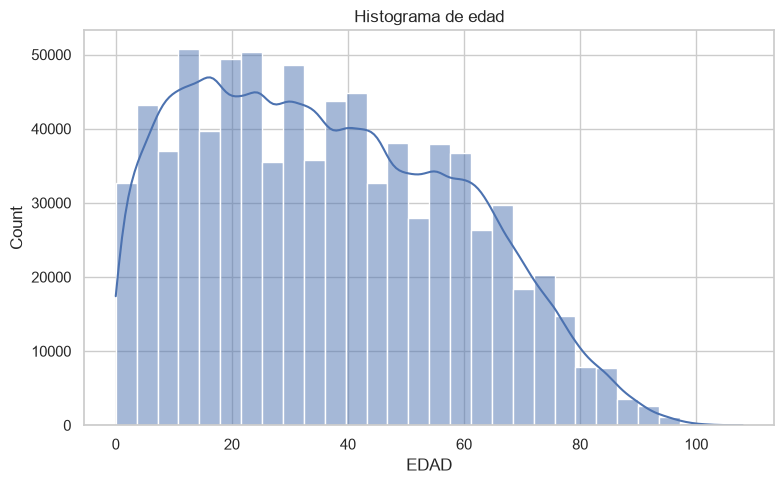

In [27]:
if 'EDAD' in base.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(base['EDAD'].dropna(), bins=30, kde=True)
    plt.title('Histograma de edad')
    plt.tight_layout()
    plt.savefig(FIGURES / 'hist_edad.png', dpi=300)
    plt.show()

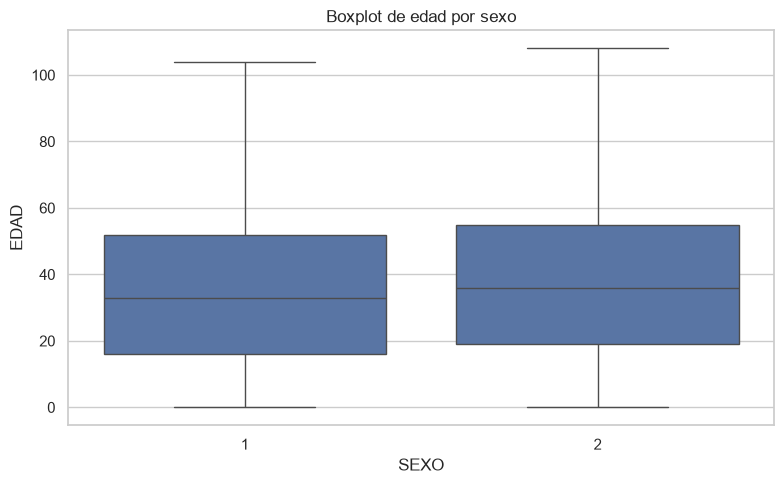

In [29]:
if 'SEXO' in base.columns and 'EDAD' in base.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=base, x='SEXO', y='EDAD')
    plt.title('Boxplot de edad por sexo')
    plt.tight_layout()
    plt.savefig(FIGURES / 'boxplot_edad_sexo.png', dpi=300)
    plt.show()

In [30]:
serie = base['EDAD'].dropna() if 'EDAD' in base.columns else pd.Series(dtype=float)
serie = serie.sample(min(5000, len(serie)), random_state=42) if len(serie) > 5000 else serie
if len(serie) >= 3:
    stat, p = shapiro(serie)
    print({'shapiro_stat': stat, 'p_value': p})

{'shapiro_stat': np.float64(0.9688855262133615), 'p_value': np.float64(1.361634029418902e-31)}


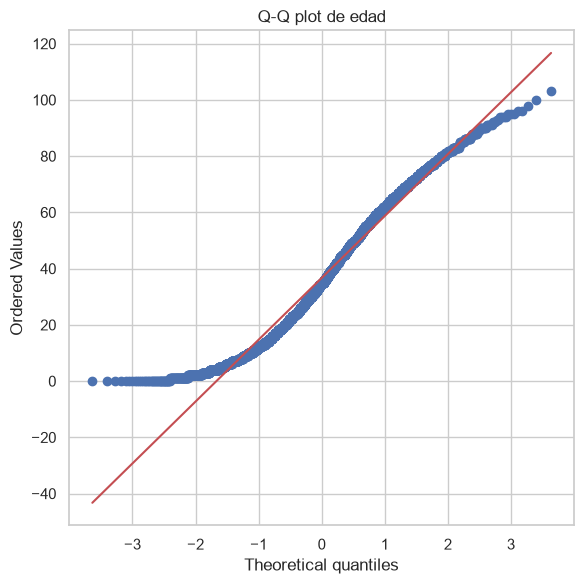

In [31]:
if len(serie) >= 3:
    plt.figure(figsize=(6,6))
    probplot(serie, dist='norm', plot=plt)
    plt.title('Q-Q plot de edad')
    plt.tight_layout()
    plt.savefig(FIGURES / 'qqplot_edad.png', dpi=300)
    plt.show()